## Team Project - Image Classifier

### Tasks
1. Create an Image Classifier (CNN model) to classify images of fruits correctly.
2. A Fruits dataset is provided that consists of these 3 classes:
    <br>o Apple only
    <br>o Orange only
    <br>o Banana only
3. Use the images in Train.zip and Test.zip to train and test your image classifier.
4. Document your experiments and results in improving your model’s accuracy.
5. The following activities can improve your model’s accuracy (for your consideration
only):
    <br>o Balance out the number of samples in each class
    <br>o Correct any mis-labelling in any of the 4 classes
    <br>o Image Augmentation to generate more data
7. Use Matplotlib to generate any plots that you think can help the reader understand your
work better.

### Steps
0. Import packages
1. Load images
2. Preprocess images and labels
3. Build CNN model
4. Compile CNN model
5. Train CNN model
6. Evaluate accuracy
7. Improve model
8. Generate evaluation graphs
9. Predict results

### Step 0. Import packages
Clear session + set random seeding as well

In [120]:
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt
import os
import random
import seaborn as sns

from tensorflow import keras
from tensorflow.keras import backend as K
from tensorflow.keras.utils import load_img, img_to_array
from tensorflow.keras import layers, models
from tensorflow.keras.models import Sequential
from tensorflow.keras.callbacks import EarlyStopping

from sklearn.metrics import confusion_matrix, classification_report
from sklearn.model_selection import train_test_split

# Clear previous tf / keras session
K.clear_session()

# Set random seeds
random.seed(42)
np.random.seed(42)
tf.random.set_seed(42)

### Step 1. Load images
Load images from train / test folders

### Step 2. Preprocess images
- Skip images that do not match pre-defined labels apple / banana / orange
- From training / test dataset, return 2 tuples of images + labels array
- In image preprocessing, standardise to 128x128 size and keep original image ratio

In [121]:
# Define labels
label_map = [ 'apple', 'banana', 'orange' ]

# HELPER FN1: Create labels from file names and append to label array
# 0 = apple, 1 = banana, 2 = orange
def append_label(labels, lower):
    for i, v in enumerate(label_map):
        if v in lower:
            labels.append(i)
            return # Exit after matched and appended

# HELPER FN2: Load and normalise image, and append to image array
def append_image(images, f, folder_path):
    # Get full image path
    path = os.path.join(folder_path, f) # Use original file name

    # Load image
    img = load_img(
        path, # With specified path
        target_size = (128, 128), # Standardise to 128x128 size
        color_mode = 'rgb', # Color mode RGB
        keep_aspect_ratio = True # Keep original img ratio
    )

    # Convert img to array
    img_array = img_to_array(img)

    # Store in images
    images.append(img_array)

In [122]:
# MAIN FN: Load images + labelling
def load_data(folder_path):
    images = []
    labels = []

    files = os.listdir(folder_path)

    for f in files:
        lower = f.lower()
        
        # Skip images not labelled as apple / banana / orange
        if not any(l in lower for l in label_map):
            continue
        
        if lower.endswith(('.jpg', '.jpeg', '.png')):

            # Append preprocessed image
            append_image(images, f, folder_path)
            
            # Append preprocessed label
            append_label(labels, lower)

    # Convert to arrays with normalisation
    X = np.array(images) / 255.0
    y = np.array(labels)

    return X, y

In [123]:
# IMPL: Extract X and y from dataset
# 1. Load images (normalised with / 255.0) from folder
# 2. Create labels from file names (apple/banana/orange)
# 3. Generate training and test data
TRAIN_DIR = '../../train'
TEST_DIR = '../../test'

X_train, y_train = load_data(TRAIN_DIR)
X_test, y_test = load_data(TEST_DIR)

print(f"\nTrain shape: {X_train.shape}\nTest shape: {X_test.shape}")
print(f"\nTrain shape: {y_train.shape}\nTest shape: {y_test.shape}")


Train shape: (220, 128, 128, 3)
Test shape: (55, 128, 128, 3)

Train shape: (220,)
Test shape: (55,)


In [124]:
# Split training data into train + validation
X_train, X_val, y_train, y_val = train_test_split(
    X_train,
    y_train,
    test_size = 0.2,
    random_state = 42,
    shuffle = True,
    stratify = y_train
)

### Step 3. Build CNN model
Layers:
- Input
- Hidden: Convolution, Pooling, Dropout
- Output

In [125]:
# FN: Build CNN model with layers
def build_model():
    return models.Sequential([

        # Input layer
        layers.Input(shape = (128, 128, 3)), # Match previous settings

        # Data augmentation
        layers.RandomFlip('horizontal'),
        layers.RandomRotation(0.1),
        layers.RandomZoom(0.1),

        # Convolution layer 1: extract image features
        layers.Conv2D(
            filters = 32, # 32 filters to learn patterns
            kernel_size = (3, 3),
            padding = 'same', # Preserve image edges
            activation = 'relu' # Non-linear
        ),

        layers.MaxPooling2D(pool_size = (2, 2)), # Reduce dimensions

        # Convolution layer 2: learn more complex features
        layers.Conv2D(
            filters = 64, # Increase depth to detect more complex patterns
            kernel_size = (3, 3),
            padding = 'same',
            activation = 'relu'
        ),

        layers.MaxPooling2D(pool_size = (2, 2)),

        # Convolution layer 3: Learn high-level features
        layers.Conv2D(
            filters = 128,
            kernel_size = (3, 3),
            padding = 'same',
            activation = 'relu'
        ),

        layers.MaxPooling2D(pool_size = (2, 2)),

        # Flatten layer: convert to 1D vector (4M+ params) 
        layers.Flatten(),

        # Dense layer: Fully connected layer
        layers.Dense(
            units = 128,
            activation = 'relu'
        ),

        # Dropout layer: Reduce overfitting
        layers.Dropout(0.5),

        # Output layer
        layers.Dense(
            units = 3,
            activation = 'softmax' # Convert to probabilities
        )
        
    ])

In [126]:
# IMPL: Build CNN model
model = build_model()

### Step 4. Compile CNN model
Params:
- Optimiser: adam
- Loss: sparse_categorical_crossentropy
- Metrics: accuracy

In [127]:
# FN2: Compile model
def compile_model(model):
    model.compile(
        optimizer = 'adam', # Update weights while learning
        loss = 'sparse_categorical_crossentropy', # Bc labels are 0, 1, 2
        metrics = ['accuracy'] # Measure correct / total preds
    )

In [128]:
# IMPL: Compile CNN model + summary
compile_model(model)
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━┓
┃ Layer (type)          ┃ Output Shape    ┃  Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━┩
│ random_flip           │ (None, 128,     │        0 │
│ (RandomFlip)          │ 128, 3)         │          │
├───────────────────────┼─────────────────┼──────────┤
│ random_rotation       │ (None, 128,     │        0 │
│ (RandomRotation)      │ 128, 3)         │          │
├───────────────────────┼─────────────────┼──────────┤
│ random_zoom           │ (None, 128,     │        0 │
│ (RandomZoom)          │ 128, 3)         │          │
├───────────────────────┼─────────────────┼──────────┤
│ conv2d (Conv2D)       │ (None, 128,     │      896 │
│                       │ 128, 32)        │          │
├───────────────────────┼─────────────────┼──────────┤
│ max_pooling2d         │ (None, 64, 64,  │        0 │
│ (MaxPooling2D)        │ 32)             │          │
├───────────────────────┼─────────────────┼──────────┤
│ conv2d_1 (Conv2D)     │ (None, 64, 64,  │   18,496 │
│                       │ 64)             │          │
├───────────────────────┼─────────────────┼──────────┤
│ max_pooling2d_1       │ (None, 32, 32,  │        0 │
│ (MaxPooling2D)        │ 64)             │          │
├───────────────────────┼─────────────────┼──────────┤
│ conv2d_2 (Conv2D)     │ (None, 32, 32,  │   73,856 │
│                       │ 128)            │          │
├───────────────────────┼─────────────────┼──────────┤
│ max_pooling2d_2       │ (None, 16, 16,  │        0 │
│ (MaxPooling2D)        │ 128)            │          │
├───────────────────────┼─────────────────┼──────────┤
│ flatten (Flatten)     │ (None, 32768)   │        0 │
├───────────────────────┼─────────────────┼──────────┤
│ dense (Dense)         │ (None, 128)     │ 4,194,4… │
├───────────────────────┼─────────────────┼──────────┤
│ dropout (Dropout)     │ (None, 128)     │        0 │
├───────────────────────┼─────────────────┼──────────┤
│ dense_1 (Dense)       │ (None, 3)       │      387 │
└───────────────────────┴─────────────────┴──────────┘

 Total params: 4,288,067 (16.36 MB)

 Trainable params: 4,288,067 (16.36 MB)

 Non-trainable params: 0 (0.00 B)

### Step 5. Train CNN model

In [129]:
# Early stopping
early_stop = EarlyStopping(
    monitor = 'val_accuracy', # Monitor accuracy as data size is relatively small
    patience = 5, # Allow 5 epochs without improvement before stopping
    mode = 'max', # the higher the accuracy the better
    restore_best_weights = True # Restore weight from best epoch
)

# FN: Train model
def train_model(model, X_train, y_train, X_test, y_test):
    return model.fit(
        X_train,
        y_train,
        epochs = 20,
        batch_size = 32,
        validation_data = (X_val, y_val),
        callbacks = [early_stop] # use early stopping
    )

In [130]:
# IMPL: Train model
history = train_model(model, X_train, y_train, X_test, y_test)

# Print best epoch
best_epoch = np.argmax(history.history['val_accuracy']) + 1
print('Best epoch:', best_epoch)

Epoch 1/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 2s 198ms/step - accuracy: 0.3864 - loss: 1.7849 - val_accuracy: 0.3409 - val_loss: 1.0690
Epoch 2/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 169ms/step - accuracy: 0.4716 - loss: 1.0744 - val_accuracy: 0.6136 - val_loss: 0.9502
Epoch 3/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 172ms/step - accuracy: 0.6136 - loss: 0.9133 - val_accuracy: 0.8864 - val_loss: 0.6668
Epoch 4/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 170ms/step - accuracy: 0.7102 - loss: 0.7098 - val_accuracy: 0.8409 - val_loss: 0.5140
Epoch 5/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 163ms/step - accuracy: 0.8295 - loss: 0.5603 - val_accuracy: 0.9091 - val_loss: 0.2916
Epoch 6/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 163ms/step - accuracy: 0.8864 - loss: 0.3852 - val_accuracy: 0.9318 - val_loss: 0.2764
Epoch 7/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 169ms/step - accuracy: 0.8864 - loss: 0.2974 - val_accuracy: 0.9318 - val_loss: 0.2088
Epoch 8/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 171ms/step - accuracy: 0.9205 - loss: 0.2112 - val_accuracy: 0.9318 - val_loss:

### Step 6. Evaluate accuracy
1. Evaluate accuracy of model
2. Investigate misclassified images

In [131]:
# IMPL: Evaluate model
test_loss, test_accuracy = model.evaluate(X_test, y_test)
print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

# Classification report
y_pred_probs = model.predict(X_test)
y_pred = np.argmax(y_pred_probs, axis = 1)

print(classification_report(
    y_test,
    y_pred,
    target_names = label_map
))

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - accuracy: 0.9636 - loss: 0.2846
Test Loss: 0.28462961316108704
Test Accuracy: 0.9636363387107849
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 97ms/step
              precision    recall  f1-score   support

       apple       0.95      1.00      0.97        19
      banana       1.00      0.89      0.94        18
      orange       0.95      1.00      0.97        18

    accuracy                           0.96        55
   macro avg       0.97      0.96      0.96        55
weighted avg       0.97      0.96      0.96        55



[28 30]


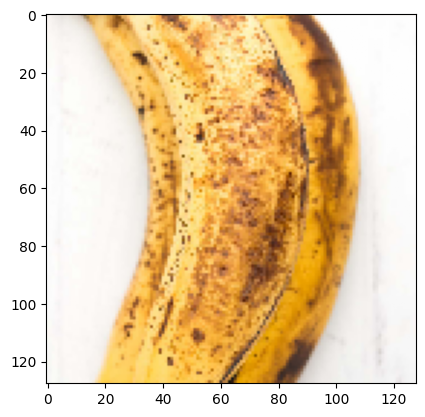

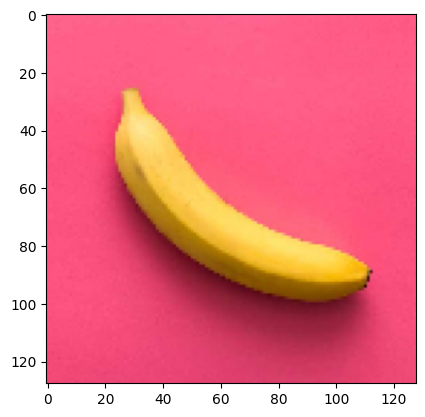

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
[[0.01252888 0.1785738  0.8088973 ]]


In [132]:
# Investigate misclassified images
misclass = np.where(y_pred != y_test)[0]
print(misclass)

plt.imshow(X_test[misclass[0]])
plt.show()

plt.imshow(X_test[misclass[1]])
plt.show()

pred = model.predict(
    X_test[misclass[0]].reshape(1,128,128,3)
)
print(pred)

## From results, the 2 misclassified images are due to blur

### Step 7. Improve model
Changes made to improve model performance:
1. To avoid overfitting, implemented layers.Dropout(0.5)
2. Added data augmentation BEFORE hidden layers to build_model() to generate image variations
3. Added early stopping when fitting model to improve generalisation and reduce overfitting

### Step 8. Generate evaluation graphs
1. Training + Validation Accuracy
2. Training + Validation Loss
3. Confusion matrix

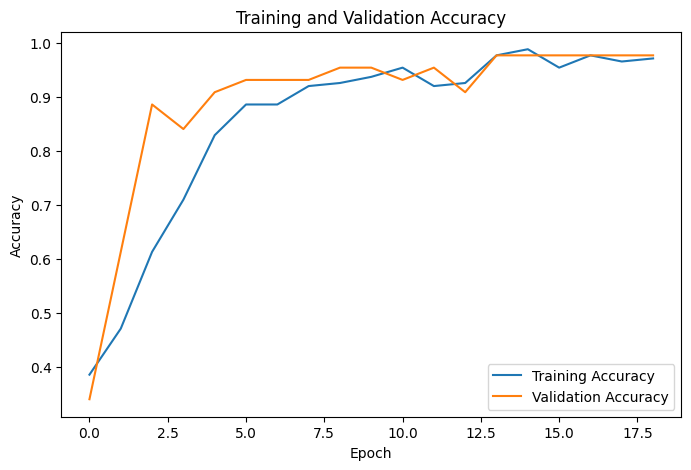

In [133]:
# Training and Validation Accuracy

plt.figure(figsize = (8, 5))

plt.plot(history.history['accuracy'], label = 'Training Accuracy')
plt.plot(history.history['val_accuracy'], label = 'Validation Accuracy')

plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training and Validation Accuracy')
plt.legend()
plt.show()

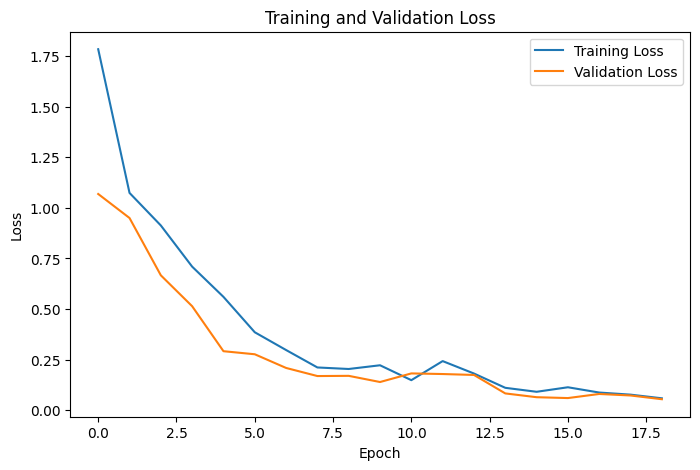

In [134]:
# Training and Validation Loss

plt.figure(figsize = (8, 5))

plt.plot(history.history['loss'], label = 'Training Loss')
plt.plot(history.history['val_loss'], label = 'Validation Loss')

plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()
plt.show()

[[19  0  0]
 [ 1 16  1]
 [ 0  0 18]]


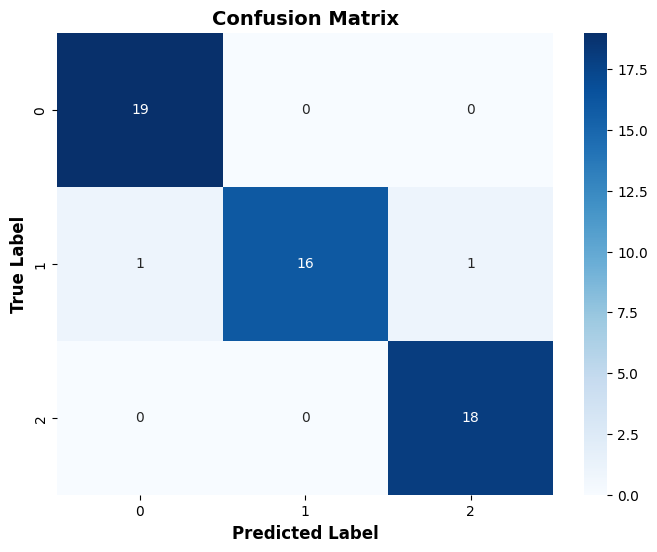

In [135]:
# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
print(cm)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix', fontsize=14, fontweight='bold')
plt.xlabel('Predicted Label', fontsize=12, fontweight='bold')
plt.ylabel('True Label', fontsize=12, fontweight='bold')
plt.show()

### Step 9. Predict results
1. Batch
2. Single

In [136]:
y_pred_prob = model.predict(X_test)

# Convert probabilities to class labels
y_pred = np.argmax(y_pred_prob, axis=1)

print("First 20 predicted labels:", y_pred[:20])
print("First 20 true labels:", y_test[:20])

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
First 20 predicted labels: [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1]
First 20 true labels: [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1]


In [137]:
# FN: Preprocess for prediction
def preprocess_image(image_path):
    images = []

    # Get folder path and file name
    folder_path = os.path.dirname(image_path)
    f = os.path.basename(image_path)

    # Preprocess
    append_image(images, f, folder_path)

    # Convert to numpy array and return
    return np.array(images) / 255.0

In [138]:
# FN: Predict image
def predict_image(model, image_path):
    X = preprocess_image(image_path)

    # Predict probabilities
    pred = model.predict(X)

    # Get highest prob index
    pred_idx = np.argmax(pred)

    # Convert idx to label
    pred_label = label_map[pred_idx]
    print('Prediction:', pred_label)

    # Get confidence score
    conf_score = pred[0][pred_idx]
    print('Confidence score:', conf_score)

    # Print all probs
    print('\nClass probabilities:')
    for i, prob in enumerate(pred[0]):
        print(f"{label_map[i]}: {prob:.4f}")

    # Show image
    img = load_img(image_path)

    # plt
    plt.imshow(img)
    plt.title(f"This is a(n): {pred_label}")
    plt.axis('off')
    plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
Prediction: apple
Confidence score: 0.9993166

Class probabilities:
apple: 0.9993
banana: 0.0005
orange: 0.0001


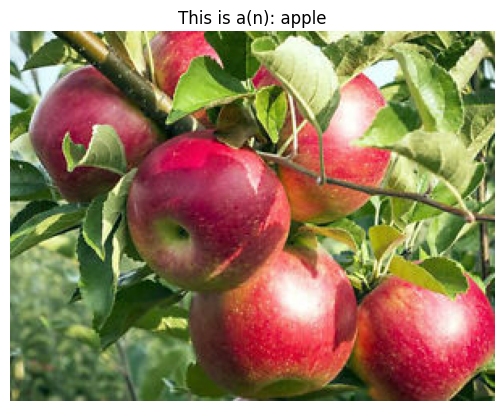

In [139]:
# Take image from test folder
IMAGE_PATH = '../../test/apple_77.jpg'

# IMPL: Predict image
predict_image(
    model,
    IMAGE_PATH
)